# N3 · 评测 harness: 同模型, 换配置, 看成败与成本 (配套 L10)

固定模型(Mock)和任务, 只变 harness 配置 (compaction? hook?), 测成功率与上下文成本。
坐实「同模型换 harness 改变结果」。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import provider, compaction, long_horizon, otel_trace, harness_eval
print("src 组件就绪 (默认 MockProvider, 无需 API key)")

src 组件就绪 (默认 MockProvider, 无需 API key)


In [2]:
import tempfile, pandas as pd
from harness_eval import evaluate, default_configs

rows = evaluate(default_configs(), tempfile.mkdtemp(), total_steps=6, early_stop_at=2)
df = pd.DataFrame(rows)
print(df[["harness","config","success","windows","steps","context_tokens"]].to_string(index=False))

          harness                   config  success  windows  steps  context_tokens
          A_naive compaction=off, hook=off    False        1      2             346
      B_hook_only  compaction=off, hook=on     True        2      6            2274
C_hook_compaction   compaction=on, hook=on     True        2      6            1382


## 两个旋钮的作用: hook→成败, compaction→成本

C:\Users\ericp\AppData\Local\Temp\ipykernel_83164\1946568746.py:10: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_83164\1946568746.py:10: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_83164\1946568746.py:10: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_83164\1946568746.py:10: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_83164\1946568746.py:10: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\i

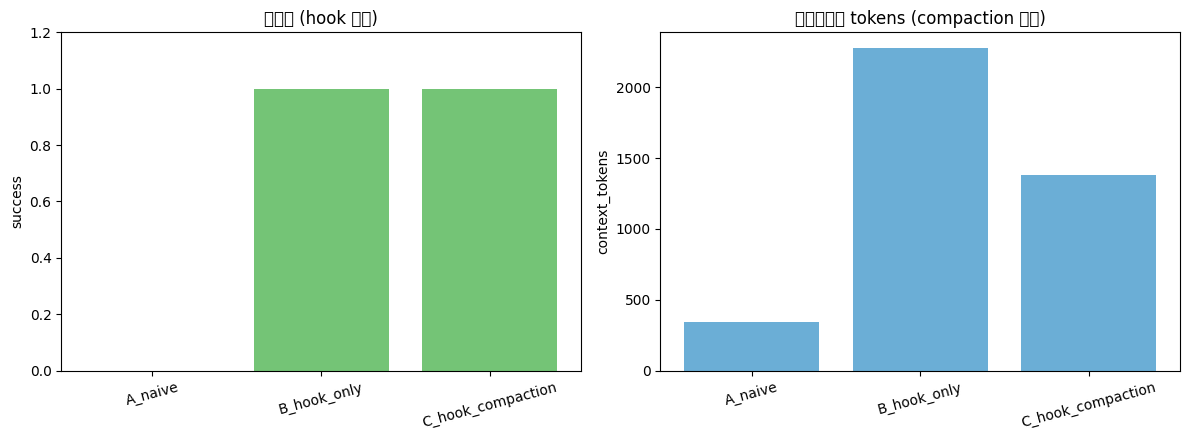

无 hook 的 A_naive 成功: False
C(hook+compaction) 比 B(仅hook) 省 tokens: 892


In [3]:
import matplotlib.pyplot as plt
fig, (a1,a2) = plt.subplots(1,2, figsize=(12,4.5))
colors = ["#fb6a4a" if not s else "#74c476" for s in df["success"]]
a1.bar(df["harness"], df["success"].astype(int), color=colors)
a1.set_title("成功率 (hook 决定)"); a1.set_ylim(0,1.2); a1.set_ylabel("success")
a2.bar(df["harness"], df["context_tokens"], color="#6baed6")
a2.set_title("上下文成本 tokens (compaction 决定)"); a2.set_ylabel("context_tokens")
for ax in (a1,a2):
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

ok = df.set_index("harness")
print("无 hook 的 A_naive 成功:", bool(ok.loc['A_naive','success']))
print("C(hook+compaction) 比 B(仅hook) 省 tokens:",
      int(ok.loc['B_hook_only','context_tokens'] - ok.loc['C_hook_compaction','context_tokens']))

**收获**: `A_naive` (无 hook) 失败; `B/C` (有 hook) 成功; `C` (再加 compaction) 成本更低。**harness 是性能的自变量**——这正是 SWE-bench 上同模型换 harness 差几十分的微缩版。